In [2]:
import torch
import torchvision
import torchvision.transforms as transforms

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5))
])

In [4]:
trainset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [00:01<00:00, 93.0MB/s]


In [5]:
trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=128,
    shuffle=True,
    num_workers=2
)

testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=100,
    shuffle=False,
    num_workers=2
)

In [6]:
print(len(trainset))  # should be 50000
print(len(testset))   # should be 10000

50000
10000


In [7]:
dataiter = iter(trainloader)
images, labels = next(dataiter)

print(images.shape)  # expected: [128, 3, 32, 32]
print(labels.shape)  # expected: [128]

torch.Size([128, 3, 32, 32])
torch.Size([128])


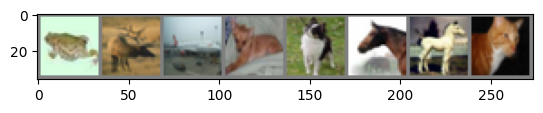

In [8]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img / 2 + 0.5  # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

imshow(torchvision.utils.make_grid(images[:8]))

In [9]:
import torchvision.models as models

model = models.resnet18(num_classes=10)

outputs = model(images)
print(outputs.shape)  # expected: [128, 10]

torch.Size([128, 10])


In [10]:
import torchvision.models as models

model = models.resnet18(num_classes=10)

outputs = model(images)
print(outputs.shape)  # expected: [128, 10]

torch.Size([128, 10])


In [11]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# Run just 1 batch
model.train()

for images, labels in trainloader:
    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    print("Loss:", loss.item())
    break

Loss: 2.5785865783691406
